# Baseline CNN

Treinamento de uma CNN simples, do zero, usando os splits e DataLoaders existentes do PlantVillage. O conjunto de teste fica reservado para a avaliacao final.

## Caminhos e ambiente

In [1]:
from pathlib import Path
import importlib.util
import subprocess
import sys

try:
    from google.colab import drive
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

MOUNT_DRIVE = False
if IN_COLAB and MOUNT_DRIVE:
    drive.mount("/content/drive")


def find_project_root() -> Path:
    current = Path.cwd().resolve()
    candidates = [current, *current.parents]
    if IN_COLAB:
        candidates.append(Path("/content/tcc-plant-disease-classification"))

    for candidate in candidates:
        if (candidate / "src" / "plantvillage_pytorch.py").exists():
            return candidate

    return Path("/content/tcc-plant-disease-classification") if IN_COLAB else current


BASE_DIR = find_project_root()
DATA_DIR = BASE_DIR / "data"
RESULTS_DIR = BASE_DIR / "results"
SRC_DIR = BASE_DIR / "src"

# Ajuste estes caminhos se os arquivos estiverem em outro local em /content/.
ZIP_PATH = DATA_DIR / "data.zip"
LEAF_MAP_PATH = DATA_DIR / "leaf_grouping" / "leaf-map.json"
RAW_METADATA_CSV = RESULTS_DIR / "plantvillage_metadata_raw_color.csv"
METADATA_CSV = RESULTS_DIR / "plantvillage_metadata_split.csv"
IMAGE_ROOT = Path("/content/plantvillage_color") if IN_COLAB else DATA_DIR / "plantvillage_color"
CHECKPOINT_DIR = Path("/content/baseline_cnn") if IN_COLAB else RESULTS_DIR / "baseline_cnn"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

if not SRC_DIR.exists():
    raise FileNotFoundError(f"Diretorio src nao encontrado: {SRC_DIR}")

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

print("Base:", BASE_DIR)
print("Dados:", DATA_DIR)
print("Resultados:", RESULTS_DIR)
print("Imagens:", IMAGE_ROOT)
print("Checkpoints:", CHECKPOINT_DIR)

Base: C:\Users\cw_58\Documents\tcc-plant-disease-classification
Dados: C:\Users\cw_58\Documents\tcc-plant-disease-classification\data
Resultados: C:\Users\cw_58\Documents\tcc-plant-disease-classification\results
Imagens: C:\Users\cw_58\Documents\tcc-plant-disease-classification\data\plantvillage_color
Checkpoints: C:\Users\cw_58\Documents\tcc-plant-disease-classification\results\baseline_cnn


In [2]:
required_packages = {
    "torch": "torch",
    "torchvision": "torchvision",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
}
missing_packages = [
    package
    for module_name, package in required_packages.items()
    if importlib.util.find_spec(module_name) is None
]

if missing_packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing_packages])

import pandas as pd
import torch
from torch import nn, optim
import matplotlib.pyplot as plt

## Configuracao do treino

In [3]:
SEED = 42
NUM_CLASSES = 38
BATCH_SIZE = 32
EPOCHS = 10
LEARNING_RATE = 0.001
NUM_WORKERS = 2 if IN_COLAB else 0

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("GPU disponivel:", torch.cuda.is_available())
if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("Usando CPU")

GPU disponivel: True
GPU: NVIDIA GeForce RTX 5060


In [4]:
from baseline_cnn import create_baseline_cnn
from plantvillage_audit import build_metadata_dataframe, save_metadata_csv
from plantvillage_pytorch import create_dataloaders, extract_raw_color_from_zip
from plantvillage_split import save_split_metadata_csv, split_metadata_by_leaf_id
from train_baseline import count_parameters, save_history, set_seed, train_model

## Arquivos do PlantVillage

In [5]:
DOWNLOAD_DATA_IF_MISSING = True
EXTRACT_IMAGES_IF_MISSING = True

if DOWNLOAD_DATA_IF_MISSING and (not ZIP_PATH.exists() or not LEAF_MAP_PATH.exists()):
    if importlib.util.find_spec("huggingface_hub") is None:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "huggingface_hub"])
    from huggingface_hub import hf_hub_download

    DATA_DIR.mkdir(parents=True, exist_ok=True)
    if not ZIP_PATH.exists():
        ZIP_PATH = Path(
            hf_hub_download(
                repo_id="mohanty/PlantVillage",
                filename="data.zip",
                repo_type="dataset",
                local_dir=str(DATA_DIR),
            )
        )
    if not LEAF_MAP_PATH.exists():
        LEAF_MAP_PATH = Path(
            hf_hub_download(
                repo_id="mohanty/PlantVillage",
                filename="leaf_grouping/leaf-map.json",
                repo_type="dataset",
                local_dir=str(DATA_DIR),
            )
        )

if not METADATA_CSV.exists():
    if not ZIP_PATH.exists() or not LEAF_MAP_PATH.exists():
        raise FileNotFoundError(
            "CSV de split ausente e arquivos base nao encontrados. "
            "Ajuste ZIP_PATH e LEAF_MAP_PATH para os caminhos corretos."
        )
    print("CSV de split ausente; gerando com a logica atual do repositorio.")
    metadata = build_metadata_dataframe(ZIP_PATH, LEAF_MAP_PATH)
    save_metadata_csv(metadata, RAW_METADATA_CSV)
    metadata_split = split_metadata_by_leaf_id(metadata)
    save_split_metadata_csv(metadata_split, METADATA_CSV)
else:
    print("CSV de split encontrado:", METADATA_CSV)

image_root_has_files = IMAGE_ROOT.exists() and any(IMAGE_ROOT.iterdir())
if EXTRACT_IMAGES_IF_MISSING and not image_root_has_files:
    if not ZIP_PATH.exists():
        raise FileNotFoundError(f"ZIP nao encontrado para extracao: {ZIP_PATH}")
    print("Extraindo imagens raw/color para:", IMAGE_ROOT)
    extraction_summary = extract_raw_color_from_zip(ZIP_PATH, IMAGE_ROOT)
    print(extraction_summary)
else:
    print("Diretorio de imagens encontrado:", IMAGE_ROOT)

CSV de split encontrado: C:\Users\cw_58\Documents\tcc-plant-disease-classification\results\plantvillage_metadata_split.csv
Diretorio de imagens encontrado: C:\Users\cw_58\Documents\tcc-plant-disease-classification\data\plantvillage_color


## DataLoaders

In [6]:
set_seed(SEED)

dataloaders = create_dataloaders(
    metadata_csv=METADATA_CSV,
    image_root=IMAGE_ROOT,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    seed=SEED,
    pin_memory=device.type == "cuda",
)

split_sizes = {split: len(loader.dataset) for split, loader in dataloaders.items()}
num_classes = len(dataloaders["train"].dataset.classes)
print("Tamanhos dos splits:", split_sizes)
print("Classes:", num_classes)
print("O split test foi criado pelo helper existente, mas nao sera usado neste notebook.")

Tamanhos dos splits: {'train': 38008, 'validation': 8172, 'test': 8125}
Classes: 38
O split test foi criado pelo helper existente, mas nao sera usado neste notebook.


## Modelo

In [7]:
model = create_baseline_cnn(num_classes=NUM_CLASSES).to(device)

print(model)
print(f"Parametros totais: {count_parameters(model):,}")
print(f"Parametros treinaveis: {count_parameters(model, trainable_only=True):,}")

BaselineCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Dropout2d(p=0.1, inplace=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout2d(p=0.15, inplace=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (11): Dropout2d(p=0.2, inplace=False)
    (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (15): Dropout2d(p=0.25, inplace=False)
  )
  (pool): AdaptiveAvgPool2d(output_

## Treinamento

In [9]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
BEST_CHECKPOINT_PATH = CHECKPOINT_DIR / "baseline_cnn_best.pth"

history = train_model(
    model=model,
    dataloaders=dataloaders,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    epochs=EPOCHS,
    checkpoint_path=BEST_CHECKPOINT_PATH,
)

history_csv = save_history(history, CHECKPOINT_DIR / "baseline_cnn_history.csv")
print("Historico salvo em:", history_csv)
print("Melhor checkpoint salvo em:", BEST_CHECKPOINT_PATH)

KeyboardInterrupt: 

## Historico e graficos

,epoch,train_loss,train_accuracy,validation_loss,validation_accuracy
0,1,2.332365,0.364450,1.535187,0.535854
1,2,1.562555,0.543412,1.022225,0.690162
2,3,1.248415,0.628078,0.876528,0.724547
3,4,1.057680,0.680988,0.696685,0.786833
4,5,0.931553,0.720217,0.611205,0.823421
5,6,0.822348,0.749421,0.548595,0.838962
6,7,0.740068,0.777257,0.481929,0.850098
7,8,0.696913,0.788202,0.445616,0.864782
8,9,0.654252,0.800489,0.407944,0.878243
9,10,0.611925,0.811408,0.332581,0.908346


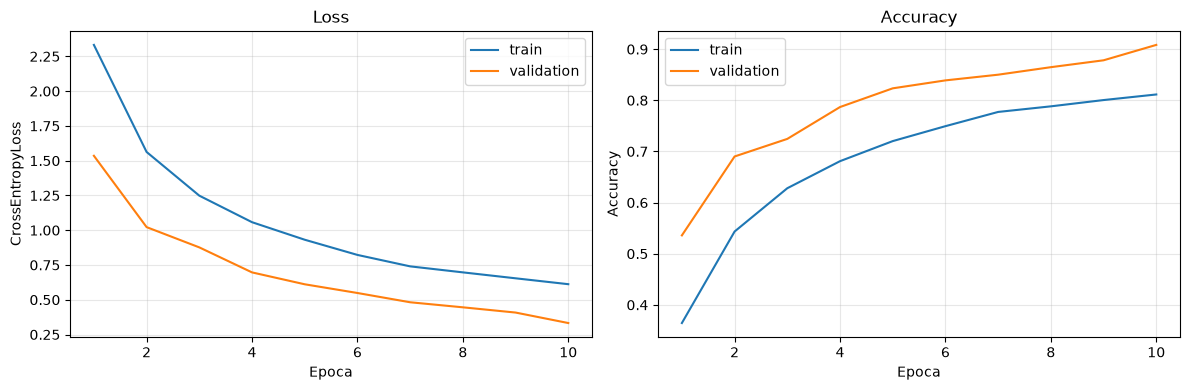

In [10]:
history_df = pd.DataFrame(history)
display(history_df)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_df["epoch"], history_df["train_loss"], label="train")
axes[0].plot(history_df["epoch"], history_df["validation_loss"], label="validation")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoca")
axes[0].set_ylabel("CrossEntropyLoss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history_df["epoch"], history_df["train_accuracy"], label="train")
axes[1].plot(history_df["epoch"], history_df["validation_accuracy"], label="validation")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoca")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [11]:
best_row = history_df.loc[history_df["validation_loss"].idxmin()]
checkpoint = torch.load(BEST_CHECKPOINT_PATH, map_location="cpu")

print(f"Melhor epoca: {int(best_row['epoch'])}")
print(f"Validation loss: {best_row['validation_loss']:.4f}")
print(f"Validation accuracy: {best_row['validation_accuracy']:.4f}")
print("Checkpoint:", BEST_CHECKPOINT_PATH)
print("Epoca salva no checkpoint:", checkpoint["epoch"])

Melhor epoca: 10
Validation loss: 0.3326
Validation accuracy: 0.9083
Checkpoint: C:\Users\cw_58\Documents\tcc-plant-disease-classification\results\baseline_cnn\baseline_cnn_best.pth
Epoca salva no checkpoint: 10
